# Hello, Numerai

Hello and welcome to the Numerai Data Science Tournament!

This notebook is designed to help you build your first machine learning model and start competing in the tournament.

In this notebook we will
1. Download and explore the Numerai dataset
2. Train and evaluate your first machine learning model
3. Deploy your model to start making live submissions

In [1]:
# Install dependencies
!pip install -q numerapi pandas numerai-tools pyarrow matplotlib scikit-learn scipy cloudpickle==3.1.1

# Inline plots
%matplotlib inline

In [2]:

import os
import json
import gc
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numerapi import NumerAPI
from numerai_tools.scoring import numerai_corr

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from sklearn.impute import SimpleImputer
from sklearn.base import clone

import xgboost as xgb
import cloudpickle


## Global configurations

In [3]:
# Research knobs
ERA_STRIDE = 4
INTERNAL_VALID_ERAS = 24
TOP_K_INITIAL = 140
MAX_CLUSTER_CORR = 0.90
SUBSET_CANDIDATES = [40, 80, 120, 160]
TARGET_COL = "target"
RANDOM_STATE = 42
EAR_COL = "era"
# Set data version to one of the latest datasets
DATA_VERSION = "v5.2"

## 1. Explore data set - High Level

At a high level, the Numerai dataset is a tabular dataset that describes the stock market over time. It is compiled from high-quality (and expensive) data that might be difficult for individuals to obtain.


### Training data

Each row represents a stock at a specific point in time:
- `id` is the stock id
- `era` is the date
- `target` is a measure of future returns for that stock
- `features` describe the attributes of the stock (eg. P/E ratio) for that date

In [5]:
# Initialize NumerAPI - the official Python API client for Numerai
napi = NumerAPI()

# # list the datasets and available versions
# all_datasets = napi.list_datasets()
# dataset_versions = list(set(d.split('/')[0] for d in all_datasets))
# print("Available versions:\n", dataset_versions)

def download_numerai_data(data_version="v5.2"):

  napi.download_dataset(f"{DATA_VERSION}/features.json")

  for fname in ["train.parquet", "validation.parquet", "live.parquet"]:
    napi.download_dataset(f"{DATA_VERSION}/{fname}")

  print("Downloaded data")


# download the feature metadata file
napi.download_dataset(f"{DATA_VERSION}/features.json")

# read the metadata and display
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))


# Define our feature set
feature_set = feature_metadata["feature_sets"]["medium"] # all


# Download training, validation and testing data
# for fname in ["train.parquet", "validation.parquet", "live.parquet"]:
#     napi.download_dataset(f"{DATA_VERSION}/{fname}")

# Load only the "medium" feature set to
# Use the "all" feature set to use all features
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# validation = pd.read_parquet(
#     f"{DATA_VERSION}/validation.parquet",
#     columns=["era", "target"] + feature_set
# )

# live = pd.read_parquet(
#     f"{DATA_VERSION}/live.parquet",
#     columns=["era", "target"] + feature_set
# )
# Downsample to every 4th era to reduce memory usage and speedup model training (suggested for Colab free tier)
# Comment out the line below to use all the data
train = train[train["era"].isin(train["era"].unique())]


### Eras
As mentioned above, each `era` corresponds to a different date. Each era is exactly 1 week apart.

It is helpful to think about rows of stocks within the same `era` as a single example. You will notice that throughout this notebook and other examples, we often talk about things "per era". For example, the number of rows per era represents the number of stocks in Numerai's investable universe on that date.

<Axes: title={'center': 'Number of rows per era'}, xlabel='Era'>

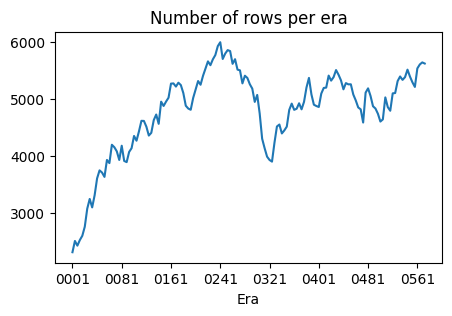

In [6]:
# Plot the number of rows per era
train.groupby("era").size().plot(
    title="Number of rows per era",
    figsize=(5, 3),
    xlabel="Era"
)

### Target
The `target` is a measure of stock market returns over the next 20 (business) days. Specifically, it is a measure of "stock-specific" returns that are not explained by well-known "factors" or broader trends in the market, country, or sector. For example, if Apple went up and the tech sector also went up, we only want to know if Apple went up more or less than the tech sector.

Target values are binned into 5 unequal bins: `0`, `0.25`, `0.5`, `0.75`, `1.0`. Again, this heavy regularization of target values is to avoid overfitting as the underlying values are extremely noisy.

<Axes: title={'center': 'Target'}, xlabel='Value', ylabel='Frequency'>

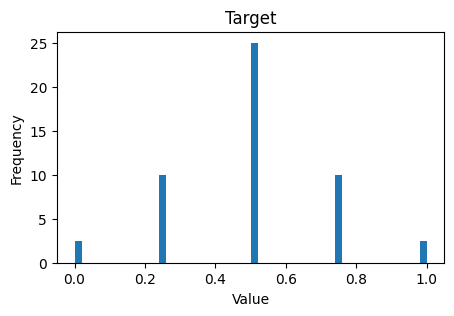

In [ ]:
# Plot density histogram of the target
train["target"].plot(
  kind="hist",
  title="Target",
  figsize=(5, 3),
  xlabel="Value",
  density=True,
  bins=50
)

In [ ]:
def get_coverage(group):
    # Returns True if the feature is NOT just the constant 2
    return group.nunique() > 1

coverage = train.groupby("era")[feature_set].apply(lambda x: (x != 2).any())
feature_coverage_ratio = coverage.mean() # % of eras where the feature exists

# Drop features that are missing in more than 20% of eras
reliable_features = feature_coverage_ratio[feature_coverage_ratio > 0.8].index.tolist()

In [ ]:
train.min()

era                                     0001
target                                   0.0
feature_able_deprived_nona                 0
feature_ablest_inflexional_egeria          0
feature_absorbable_hyperalgesic_mode       0
                                        ... 
feature_zippy_trine_diffraction            0
feature_zonal_snuffly_chemism              0
feature_zygotic_middlebrow_caribbean       0
feature_zymolytic_intertidal_privet        0
feature_zymotic_windswept_cooky            0
Length: 782, dtype: object

In [ ]:

import numpy as np

def spearman_corr(group, features, target):
    # Calculate variance (or nunique) for all features in this era
    # A constant feature has nunique == 1
    variances = group[features].nunique()

    # Identify which features are 'alive' (variance > 0)
    alive_features = variances[variances > 1].index.tolist()
    dead_features = variances[variances <= 1].index.tolist()

    # Initialize a Series of zeros for all features
    results = pd.Series(0.0, index=features)

    # Only compute correlation for features that actually move
    if alive_features:
        corrs = group[alive_features].corrwith(group[target], method='spearman')
        results[alive_features] = corrs

    return results

# Apply the safe function
era_ics = train.groupby("era").apply(lambda x: spearman_corr(x, feature_set, 'target'))
# Calculate IC per era
# We fill NaNs with 0 because a constant '2' means 0 correlation/signal
era_ics = train.groupby("era").apply(
    lambda x: x[feature_set].corrwith(x['target'], method='spearman')
).fillna(0)

# Calculate Metric: The Sharpe of the IC
feature_performance = era_ics.mean()
feature_consistency = era_ics.mean() / era_ics.std()

# Filter: Keep features with positive mean IC and a Sharpe > 0.5
selected_features = feature_consistency[feature_consistency > 0.5].index.tolist()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/cor

Reduced from 2000 to 8 features.


<Axes: title={'center': 'missing data'}, ylabel='Frequency'>

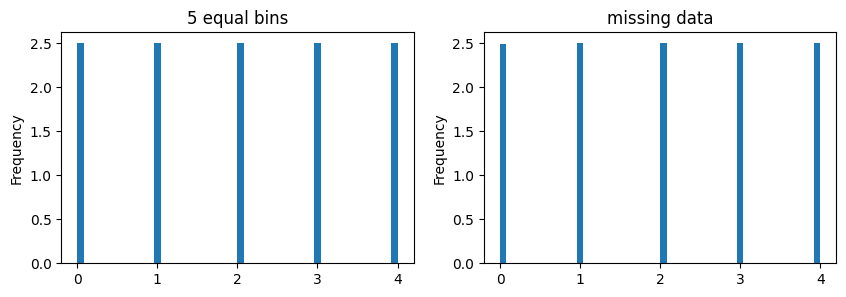

In [ ]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(
   title="5 equal bins",
   kind="hist",
   density=True,
   bins=50,
   ax=ax1
)
first_era[feature_set[-1]].plot(
   title="missing data",
   kind="hist",
   density=True,
   bins=50,
   ax=ax2
)

## 2. Modeling
At a high level, our task is to model and predict the `target` using the `features`.

### Model training

You are free to use any tool or framework, but here we will be using LGBMRegressor, a popular choice amongst tournament participants. While you wait for the model to train, watch this [video](https://www.youtube.com/watch?v=w8Y7hY05z7k) to learn why tree-based models work so well on tabular datasets from our Chief Scientist MDO.

In [ ]:
# Train and use XGBoost model
import xgboost as xgb

params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.02,
    'n_estimators': 1000,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

model = xgb.XGBRegressor(**params)

model.fit(
  train[feature_set],
  train["target"]
)


In [ ]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html
import lightgbm as lgb
import xgboost as xgb


params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.02,
    'n_estimators': 1000,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Instantiate XGBRegressor with the parameters
model = xgb.XGBRegressor(**params)



# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
# model = lgb.LGBMRegressor(
#   n_estimators=2000,
#   learning_rate=0.01,
#   max_depth=5,
#   num_leaves=2**5-1,
#   colsample_bytree=0.1
# )
# We've found the following "deep" parameters perform much better, but they require much more CPU and RAM
# model = lgb.LGBMRegressor(
#     n_estimators=30_000,
#     learning_rate=0.001,
#     max_depth=10,
#     num_leaves=2**10,
#     colsample_bytree=0.1
#     min_data_in_leaf=10000,
# )

# This will take a few minutes 🍵
model.fit(
  train[feature_set],
  train["target"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 42
[LightGBM] [Info] Start training from score 0.499946


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.01
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Validation predictions

Now let's make some out-of-sample predictions on the validation dataset to evaluate our model's performance.

In [ ]:
# Download validation data - this will take a few minutes
napi.download_dataset(f"{DATA_VERSION}/validation.parquet")

# Load the validation data and filter for data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Downsample to every 4th era to reduce memory usage and speedup evaluation (suggested for Colab free tier)
# Comment out the line below to use all the data (slower and higher memory usage, but more accurate evaluation)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Eras are 1 week apart, but targets look 20 days (o 4 weeks/eras) into the future,
# so we need to "embargo" the first 4 eras following our last train era to avoid "data leakage"
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Generate predictions against the out-of-sample validation features
# This will take a few minutes 🍵
validation["prediction"] = model.predict(validation[feature_set])
validation[["era", "prediction", "target"]]

2025-12-14 14:09:11,758 INFO numerapi.utils: starting download
v5.2/validation.parquet: 4.06GB [06:12, 10.9MB/s]                             


,era,prediction,target
id,,,
n000c290e4364875,0579,0.495463,0.50
n002a15bc5575bbb,0579,0.508138,0.25
n00309caaa0f955e,0579,0.504767,0.75
n0039cbdcf835708,0579,0.511343,0.50
n004143458984f89,0579,0.492206,0.50
...,...,...,...
nffd9cf2c992c881,1191,0.500466,0.50
nfff0fbd1837e76f,1191,0.496647,0.25
nfff3b8261e8af0a,1191,0.497235,0.25


### Performance evaluation

Numerai calculates scores designed to "align incentives" between your model and the hedge fund - a model with good scores should help the hedge fund make good returns. The primary scoring metrics in Numerai are:

- `CORR` (or "Correlation") which is calculated by the function `numerai_corr` - a Numerai specific variant of the Pearson Correlation between your model and the target.

- `MMC` (or "Meta Model Contribution") which is a calculated by the function `correlation_contribution` - a measure of how uniquely additive your model is to the Numerai Meta Model.

On the Numerai website you will see `CORR` referred to as `CORR20V2`, where the "20" refers to the 20-day return target and "v2" specifies that we are using the 2nd version of the scoring function.

In [ ]:
# install Numerai's open-source scoring tools
!pip install -q --no-deps numerai-tools

# import the 2 scoring functions
from numerai_tools.scoring import numerai_corr, correlation_contribution

# Download and join in the meta_model for the validation eras
napi.download_dataset(f"v4.3/meta_model.parquet", round_num=842)
validation["meta_model"] = pd.read_parquet(
    f"v4.3/meta_model.parquet"
)["numerai_meta_model"]


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


2025-12-14 14:15:34,656 INFO numerapi.utils: target file already exists
2025-12-14 14:15:34,658 INFO numerapi.utils: download complete


As mentioned above, it is important for us to score each historical `era` independantly. So when evaluating the performance of our model, we should be looking at the "per era" metrics.

One thing you may notice here is how low the scores are (in the range of +/- 0.05). This is very normal in the domain of quantitative finance and is part of the reason why we say Numerai is the "hardest data science tournament" in the world.

/var/folders/9t/l_bbq0y57ns1020jcy_lxsfm0000gn/T/ipykernel_32041/1642615225.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(
/var/folders/9t/l_bbq0y57ns1020jcy_lxsfm0000gn/T/ipykernel_32041/1642615225.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_mmc = validation.dropna().groupby("era").apply(


<Axes: title={'center': 'Validation MMC'}, xlabel='era'>

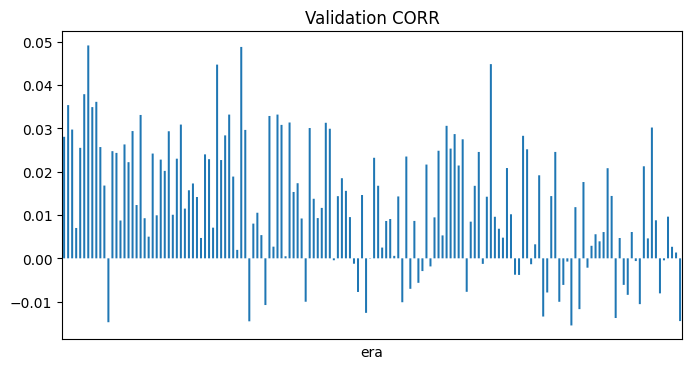

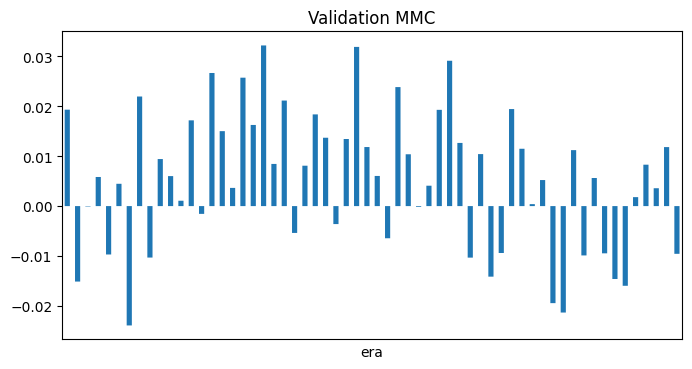

In [ ]:
# Compute the per-era corr between our predictions and the target values
per_era_corr = validation.groupby("era").apply(
    lambda x: numerai_corr(x[["prediction"]].dropna(), x["target"].dropna())
)

# Compute the per-era mmc between our predictions, the meta model, and the target values
per_era_mmc = validation.dropna().groupby("era").apply(
    lambda x: correlation_contribution(x[["prediction"]], x["meta_model"], x["target"])
)


# Plot the per-era correlation
per_era_corr.plot(
  title="Validation CORR",
  kind="bar",
  figsize=(8, 4),
  xticks=[],
  legend=False,
  snap=False
)
per_era_mmc.plot(
  title="Validation MMC",
  kind="bar",
  figsize=(8, 4),
  xticks=[],
  legend=False,
  snap=False
)

Instead of looking at the raw score for each era, it is helpful to look at the cumulative scores.

If you are familiar with "backtesting" in quant finance where people simulate the historical performance of their investment strategies, you can roughly think of this plot as a backtest of your model performance over the historical validation period.

Notice a few things below:

- CORR gradually increases over many eras of the validation data even with this simple model on modern data.

- MMC is generated over a smaller set of recent eras - this is because the validation time range pre-dates the Meta Model.

- MMC is very high early on in the Meta Model's existence, MMC - this is because the newest datasets were not available and models trained on the newest data are could have been very additive in the past.

- MMC is flat and decreasing recently because the Meta Model has started catching up to modern data sets and getting correlation has been difficult in recent eras.

<Axes: title={'center': 'Cumulative Validation MMC'}, xlabel='era'>

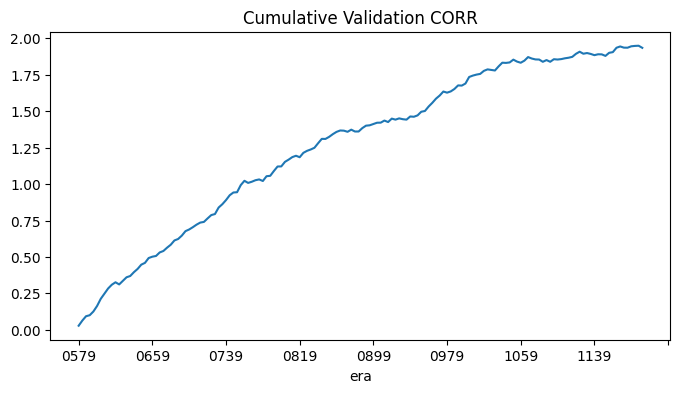

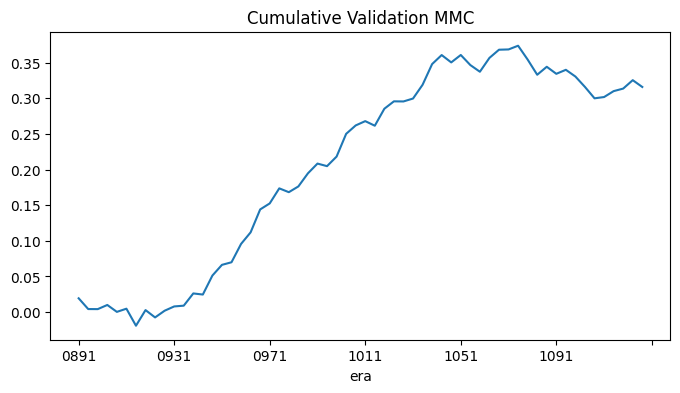

In [ ]:
# Plot the cumulative per-era correlation
per_era_corr.cumsum().plot(
  title="Cumulative Validation CORR",
  kind="line",
  figsize=(8, 4),
  legend=False
)
per_era_mmc.cumsum().plot(
  title="Cumulative Validation MMC",
  kind="line",
  figsize=(8, 4),
  legend=False
)

### Performance metrics

To evaluate the performance of our model, it is also helpful to compute some summary metrics over the entire validation period:

- `Mean` is the primary measure of your model's long-term performance.

- `Sharpe` is a measure of your model's consistency. In finance, the Sharpe ratio of an investment strategy measures risk adjusted returns. In Numerai, we compute sharpe as the mean divided by the standard deviation.

- `Max drawdown` is a measure of your model's risk. In finance, the max drawdown of an investment strategy is the largest loss suffered. In Numerai, we compute max drawdown as the maximum peak to trough drop in a cumulative score.

In [ ]:
# Compute performance metrics
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
corr_max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

mmc_mean = per_era_mmc.mean()
mmc_std = per_era_mmc.std(ddof=0)
mmc_sharpe = mmc_mean / mmc_std
mmc_max_drawdown = (per_era_mmc.cumsum().expanding(min_periods=1).max() - per_era_mmc.cumsum()).max()

pd.DataFrame({
    "mean": [corr_mean, mmc_mean],
    "std": [corr_std, mmc_std],
    "sharpe": [corr_sharpe, mmc_sharpe],
    "max_drawdown": [corr_max_drawdown, mmc_max_drawdown]
}, index=["CORR", "MMC"]).T

,CORR,MMC
mean,prediction 0.012564 dtype: float64,prediction 0.005263 dtype: float64
std,prediction 0.014682 dtype: float64,prediction 0.013668 dtype: float64
sharpe,prediction 0.855762 dtype: float64,prediction 0.385088 dtype: float64
max_drawdown,prediction 0.032412 dtype: float64,prediction 0.073799 dtype: float64


These performance metrics above are not amazing but that's ok, we are just getting started. In the next few tutorials, you will learn how to improve our model performance.

## 3. Submissions

Unlike Kaggle competitions that evalute models based on <ins>test</ins> performance, Numerai evaluates models based based on <ins>live</ins> performance.

### Live predictions

Every Tuesday-Saturday, new `live features` are released, which represent the current state of the stock market.

Your task is to generate `live predictions` on the unknown target values, which represent stock market returns 20 days into the future.

In [ ]:
# Download latest live features
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Load live features
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Generate live predictions
live_predictions = model.predict(live_features[feature_set])

# Format submission
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-12-14 14:15:37,054 INFO numerapi.utils: starting download
v5.2/live.parquet: 9.54MB [00:00, 11.2MB/s]                            


,prediction
id,
n0005e01cd27dd7b,0.507644
n000a0f321ce17e3,0.487444
n000e47c9c27ca3d,0.494772
n0016060c6335337,0.506582
n001c30cea427396,0.502284
...,...
nffcc8bf595e4e98,0.496650
nffd0c2231719dc9,0.493927
nffdbad9b545ca02,0.497923


### Model upload

To participate in the tournament, you must submit live predictions every Tuesday-Saturday.

To automate this process, you can simply:
- Define your prediction pipeline as a function
- Serialize your function using the `cloudpickle` library
- Upload your model pickle file to Numerai
- Let Numerai run your model to submit live predictions every day

Read more about Model Uploads and other self-hosted automation options in our [docs](https://docs.numer.ai/numerai-tournament/submissions#automation).


In [ ]:
# Define your prediction pipeline as a function
def predict(live_features: pd.DataFrame) -> pd.DataFrame:
    live_predictions = model.predict(live_features[feature_set])
    submission = pd.Series(live_predictions, index=live_features.index)
    return submission.to_frame("prediction")

In [ ]:
# Use the cloudpickle library to serialize your function
import cloudpickle
p = cloudpickle.dumps(predict)
with open("hello_numerai.pkl", "wb") as f:
    f.write(p)

In [ ]:
# Download file if running in Google Colab
try:
    from google.colab import files
    files.download('hello_numerai.pkl')
except:
    pass

That's it! You now have a pickle file that is ready for upload.

Head back to the [Hello Numerai Tutorial](https://numer.ai/tutorial/hello-numerai) to upload your model!